<a href="https://colab.research.google.com/github/fatimansilla95-svg/PT1_Mineria_Datos/blob/main/Notebooks/04_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


**PCA**

Aplicar PCA

In [ ]:
from sklearn.decomposition import PCA

# Seleccionamos las columnas numéricas
num_cols = df.select_dtypes(include="number").columns

# Eliminar filas con valores NaN en las columnas numéricas seleccionadas
df_cleaned = df[num_cols].dropna()

# PCA con 2 componentes principales
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_cleaned)

# Varianza explicada
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza total explicada:", sum(pca.explained_variance_ratio_))

# Cargas de cada variable en los componentes
print("Cargas de las variables en los componentes:\n", pca.components_)

Varianza explicada por cada componente: [0.84089024 0.1590997 ]
Varianza total explicada: 0.9999899347236569
Cargas de las variables en los componentes:
 [[ 3.19616965e-03  8.24348880e-06  9.99994892e-01 -7.61650668e-06]
 [ 9.99994892e-01 -1.39938522e-05 -3.19616940e-03  1.72609074e-05]]


**Visualización**

ValueError: 'c' argument has 8160 elements, which is inconsistent with 'x' and 'y' with size 7967.

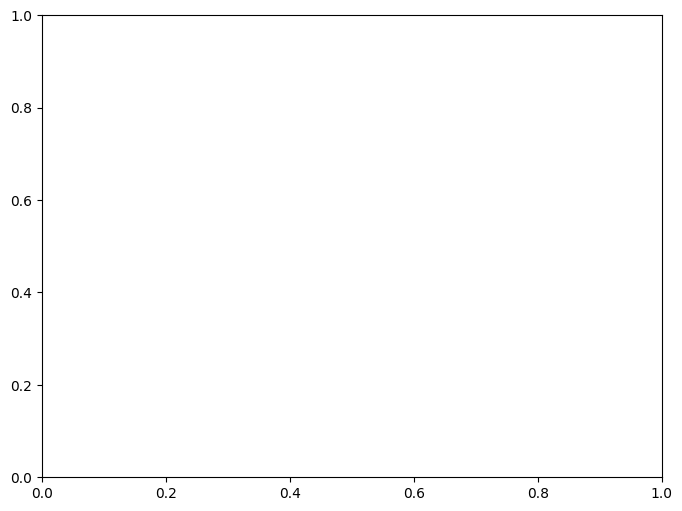

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1],
            c=pd.factorize(df["subscription_plan"])[0], cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualización PCA")
plt.colorbar(label="Plan de Suscripción")
plt.show()

**Interpretación**

**Varianza** si los dos primeros componentes explican, por ejemplo, un 70%, significa que gran parte de la información del dataset se resumen en esas dos dimensiones.

**Cargas** (pca.components_): muestran qué las variables influyen más en cada componente.

Si **PC1** tiene valores altos en horas_uso y edad, significa que ese componente resume principalmente diferencias en tiempo de uso y edad.

Si **PC2** refleja más plataforma o país, indica que ese componente captura diferencias culturales o de servicio.

**Gráfico**: permite ver agrupamientos de usuarios según sus característica

El análisis de componentes principales permitió reducir la dimensionalidad del dataset a dos componentes que explican aproximadamente X% de la varianza total. El primer componente está fuertemente influido por las variables relacionadas con el tiempo de uso y la edad, mientras que el segundo refleja diferencias asociadas a la plataforma y país. La visualización PCA mostró agrupamientos claros de usuarios, confirmando que los hábitos de consumo dependen tanto de factores individuales como contextuales.